In [26]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [31]:
# Read data
df_white = pd.read_csv("winequality-white.csv", delimiter=';')
df_red = pd.read_csv("winequality-red.csv", delimiter=';')


df_white.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Data pre-processing
HINT: Scale numerical values using *StandardScaler*

Explain what is changed.

In [33]:
# Data pre-processing: Write code
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
data_scaled = scaler.fit_transform(df_white)
data_scaled_red = scaler.fit_transform(df_red)

# Convert scaled data back to DataFrame for readability
df_scaled = pd.DataFrame(data_scaled, columns=df_white.columns)

# Print first 5 rows
df_scaled.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.172097,-0.081770,0.213280,2.821349,-0.035355,0.569932,0.744565,2.331512,-1.246921,-0.349184,-1.393152,0.13787
1,-0.657501,0.215896,0.048001,-0.944765,0.147747,-1.253019,-0.149685,-0.009154,0.740029,0.001342,-0.824276,0.13787
2,1.475751,0.017452,0.543838,0.100282,0.193523,-0.312141,-0.973336,0.358665,0.475102,-0.436816,-0.336667,0.13787
3,0.409125,-0.478657,-0.117278,0.415768,0.559727,0.687541,1.121091,0.525855,0.011480,-0.787342,-0.499203,0.13787
4,0.409125,-0.478657,-0.117278,0.415768,0.559727,0.687541,1.121091,0.525855,0.011480,-0.787342,-0.499203,0.13787


### Apply K-Means and Hierarchical (agglomerative) Clustering
Note: Apply two approaches on both winequality-white.csv and winequality-red.csv

In [34]:
# Apply K-Means Clustering: Write code
# --- K-Means Clustering ---

# -------- WHITE WINE --------
k = 4

kmeans_white = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels_white = kmeans_white.fit_predict(data_scaled)

df_white["KMeans_Cluster"] = kmeans_labels_white


# -------- RED WINE --------
kmeans_red = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels_red = kmeans_red.fit_predict(data_scaled_red)

df_red["KMeans_Cluster"] = kmeans_labels_red


# check outputs
print("White wine:")
print(df_white.head())

print("\nRed wine:")
print(df_red.head())


White wine:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  KMeans_Cluster  
0      8.8        6               0 

In [35]:
# Apply Hierarchical (agglomerative) Clustering: Write code
# --- for white wine ---
agglo = AgglomerativeClustering(n_clusters=3)
labels_white = agglo.fit_predict(data_scaled)

df_white["Hierarchical_Cluster"] = labels_white


# --- for red wine ---
agglo = AgglomerativeClustering(n_clusters=3)
labels_red = agglo.fit_predict(data_scaled_red)

df_red["Hierarchical_Cluster"] = labels_red


# just checking output
df_white.head()
df_red.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,KMeans_Cluster,Hierarchical_Cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1


### Visualizing Clusters: KMeans

Principal Component Analysis (PCA) is a powerful dimensionality reduction technique used in machine learning and data analysis to simplify complex datasets while preserving as much important information as possible. It works by transforming the original high-dimensional data into a new coordinate system where the axes (called principal components) capture the directions of maximum variance in the data. The first principal component accounts for the most variance, followed by the second, and so on. When visualizing high-dimensional data, PCA is particularly useful as it allows us to project the data into just two components (PCA1 and PCA2), enabling a meaningful 2D representation of the dataset. This transformation helps in clustering, classification, and pattern recognition by revealing inherent structures within the data. In clustering tasks like K-Means and Hierarchical Clustering, PCA aids in visualization by reducing noise and allowing us to plot the clusters effectively, making it easier to interpret patterns and relationships within the dataset.

HINT: Use Principal Component Analysis (PCA) to reduce high-dimensional data to 2 components. Use *seaborn.scatterplot*

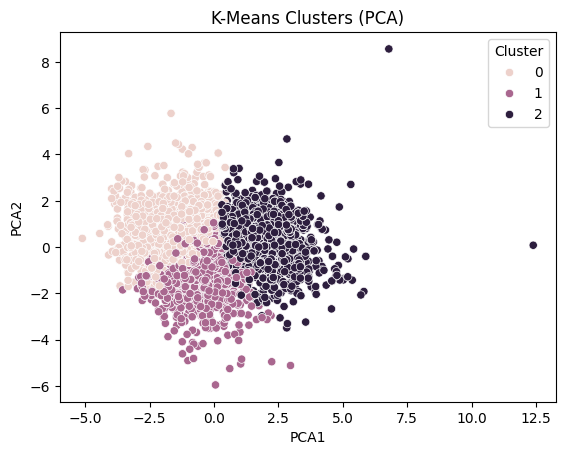

In [19]:
# Visualizing Clusters using PCA: Write code
# reduce data to 2D
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)

# make a small dataframe for plotting
df_pca = pd.DataFrame(pca_data, columns=["PCA1", "PCA2"])

# add cluster labels
df_pca["Cluster"] = kmeans_labels

# plot
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df_pca)

plt.title("K-Means Clusters (PCA)")
plt.show()



### Optimal _k_
Find the optimal number of clusters (k) using the Elbow Method.

Inertia, also known as the Within-Cluster Sum of Squares (WCSS), is a key metric used in K-Means clustering to measure how well data points are assigned to their respective clusters. It is calculated as the sum of the squared distances between each data point and the centroid of its assigned cluster.  A lower inertia value indicates that data points are closely packed around their centroids, signifying well-formed clusters.

To determine the optimal number of clusters (k), the Elbow Method is commonly used, which involves plotting inertia values for different values of k and identifying the "elbow point" - the location where the rate of decrease sharply slows down, suggesting the best balance between compact clusters and overfitting. In Python, this can be easily computed using _kmeans.inertia__ from the _sklearn.cluster.KMeans_ module. By iterating over a range of k values and plotting their corresponding inertia scores, we can visualize the optimal number of clusters. The resulting Elbow Plot helps guide the selection of k by pinpointing where adding more clusters no longer significantly reduces inertia, ensuring a well-optimized clustering solution.

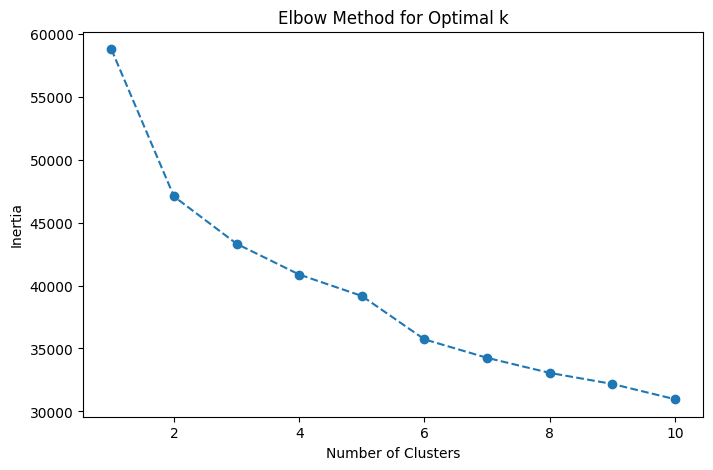

In [20]:
# Finding optimal k using Elbow Method: Write code
# checking different values of k to find the best one
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# plotting the elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')

plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()



### Visualizing Clusters: Agglomerative
 - Visualize using scatter plot - similar to KMeans
 - Generate a dendrogram to visualize hierarchical clustering.
 - Optimal k. Note: The **Silhouette Score** measures the cohesion and separation of clusters, helping determine the best k. A higher score indicates better clustering.

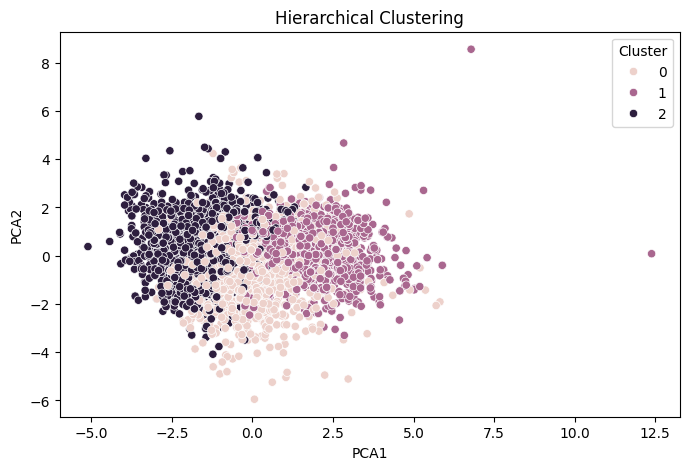

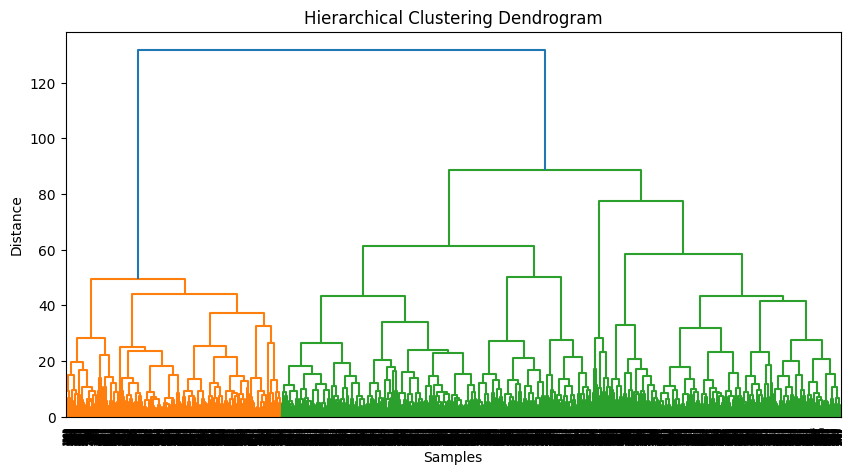

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,KMeans_Cluster,Hierarchical_Cluster
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,2,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,1,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,1,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,2,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,2,0


In [21]:
# Hierarchical Visualization: Write code
# reduce data to 2D using PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)

# make dataframe for plotting
df_pca = pd.DataFrame(pca_data, columns=["PCA1", "PCA2"])

# add agglomerative cluster labels
df_pca["Cluster"] = agglo_labels

# plot clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_pca, x="PCA1", y="PCA2", hue="Cluster")

plt.title("Hierarchical Clustering")
plt.show()


# create linkage matrix
linked = linkage(data_scaled, method='ward')

# plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

# add KMeans cluster column
df["KMeans_Cluster"] = kmeans_labels

# add Hierarchical cluster column
df["Hierarchical_Cluster"] = agglo_labels

df.head()

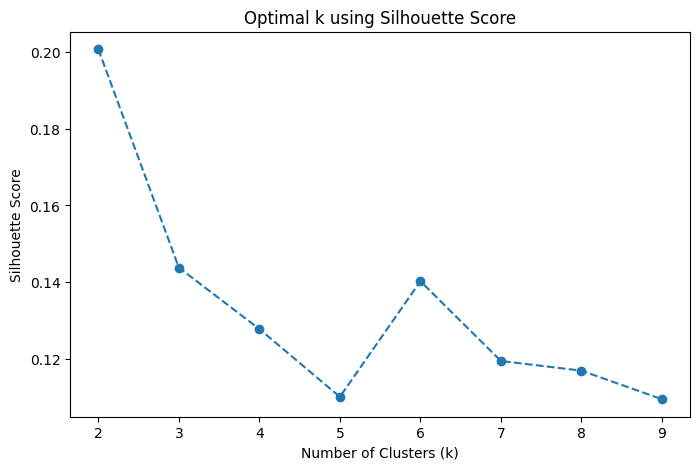

In [22]:
# Try different values of k and compute silhouette scores
silhouette_scores = []
K = range(2, 10)  # Trying values of k from 2 to 10
# Write code
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_scaled)

    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal k using Silhouette Score')
plt.show()